In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
try:
    df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', encoding='ISO-8859-1 ', sep = ';')
    print(df.columns)

except Exception as e:
    print(f'Erro: {e}')
    exit()



Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [3]:
# filtrar 

df_roubo_veiculos = df [['munic', 'roubo_veiculo']]
# print(df_roubo_veiculos.head())

# agrupar por municipio

df_roubo_veiculos = df_roubo_veiculos.groupby('munic').sum().reset_index().sort_values(by='roubo_veiculo', ascending=False)

df_roubo_veiculos

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
...,...,...
66,Rio das Flores,8
58,Porciúncula,7
46,Natividade;Varre-Sai,6
45,Miracema,6


In [9]:
# transformar dataframe em array 

roubo_veiculo_array = np.array(df_roubo_veiculos['roubo_veiculo'])

amplitude = np.max(roubo_veiculo_array) - np.min(roubo_veiculo_array)

media_roubos = np.mean(roubo_veiculo_array)

mediana_roubos = np.median(roubo_veiculo_array)

q1 = np.quantile(roubo_veiculo_array, 0.25)
q2 = np.quantile(roubo_veiculo_array, 0.50)
q3 = np.quantile(roubo_veiculo_array, 0.75)

iqr = q3 - q1

# limite superior -> identificar outliers acima de q3

limite_superior = q3 + 1.5*iqr

# limite inferior -> identificar outliers abaixo de q1

limite_inferior = q1 - 1.5*iqr

desvio = np.std(roubo_veiculo_array)

variancia = np.var(roubo_veiculo_array)

distancia_var_media = abs(variancia/media_roubos**2)

cv = desvio/media_roubos

assimetria = df_roubo_veiculos['roubo_veiculo'].skew()

kurt = df_roubo_veiculos['roubo_veiculo'].kurtosis()


In [16]:
print(f'Média: {media_roubos}')

print(f'Mediana: {mediana_roubos}')

print(f'Min: {np.min(roubo_veiculo_array)}')

print(f'Limite Inferior: {limite_inferior}')

print(f'Q1: {q1}')

print(f'Q3: {q3}')

print(f'Limite Superior: {limite_superior}')

print(f'Max: {np.max(roubo_veiculo_array)}')

print(f'Distancia Variancia - Média: {distancia_var_media}')

print(f'Coeficiente de Variação: {cv}')

print(f'Assimetria: {assimetria}')

print(f'Curtose: {kurt}')

Média: 7448.2444444444445
Mediana: 247.5
Min: 2
Limite Inferior: -1366.75
Q1: 47.0
Q3: 989.5
Limite Superior: 2403.25
Max: 372584
Distancia Variancia - Média: 28.90540358042223
Coeficiente de Variação: 5.376374575903565
Assimetria: 8.617034541386754
Curtose: 78.21644464221471


In [18]:
df_roubo_outliers_inferiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] < limite_inferior]

df_roubo_outliers_superiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] > limite_superior]


In [21]:
# Outliers inferiores:

if df_roubo_outliers_inferiores.empty:
    print(f'Não há outliers inferiores')

else:
    print(df_roubo_outliers_inferiores.sort_values(by='roubo_veiculo', ascending=True))

# Outliers Superiores

if df_roubo_outliers_superiores.empty:
    print(f'Não há outliers inferiores')

else:
    print(df_roubo_outliers_superiores.sort_values(by='roubo_veiculo', ascending=False))


Não há outliers inferiores
                    munic  roubo_veiculo
68         Rio de Janeiro         372584
23        Duque de Caxias          62574
78            São Gonçalo          52539
50            Nova Iguaçu          40235
81     São João de Meriti          30151
6            Belford Roxo          22417
48                Niterói          21646
47              Nilópolis          11952
43               Mesquita           7825
27               Itaboraí           5914
29                Itaguaí           3921
38                   Magé           3342
36                  Macaé           3248
13  Campos dos Goytacazes           3022
41                 Maricá           2663


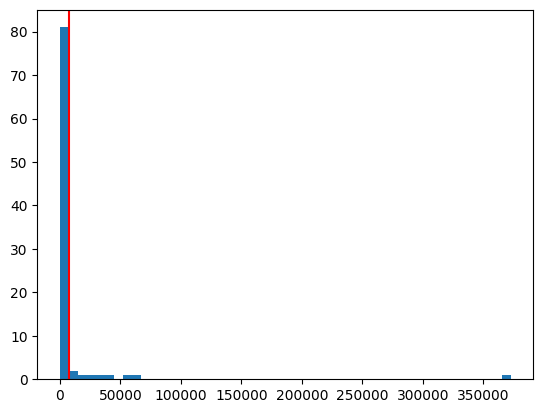

In [25]:
# Histograma

plt.hist(roubo_veiculo_array, bins=50)
plt.axvline(x=media_roubos, color='red')

Text(0.5, 1.0, 'Ranking das Cidades com Outliers Superiores')

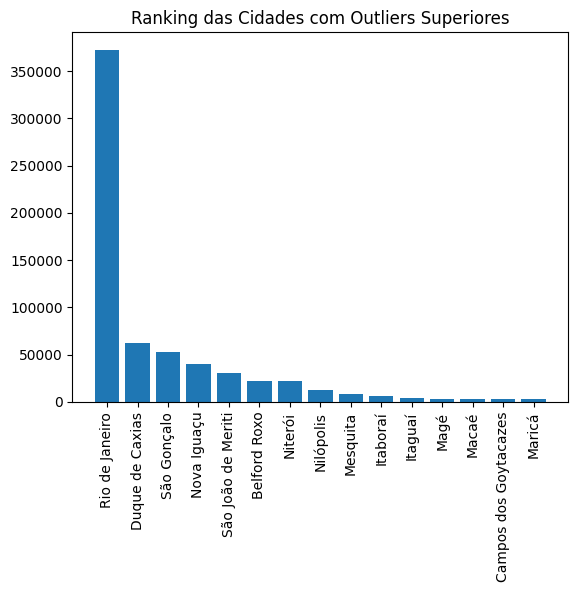

In [ ]:
# x, y
plt.bar(df_roubo_outliers_superiores['munic'], df_roubo_outliers_superiores['roubo_veiculo'])

plt.xticks(rotation=90)

plt.title('Ranking das Cidades com Outliers Superiores')



{'whiskers': [<matplotlib.lines.Line2D at 0x14983195750>,
 'caps': [<matplotlib.lines.Line2D at 0x14983196b10>,
 'boxes': [<matplotlib.lines.Line2D at 0x14983194e90>],
 'medians': [<matplotlib.lines.Line2D at 0x14983197c90>],
 'fliers': [],
 'means': [<matplotlib.lines.Line2D at 0x149831a4510>]}

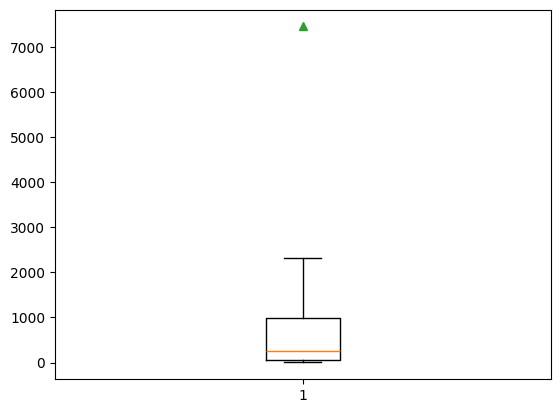

In [31]:
# showmeans (True ou False) -> True marca a média
# showfliers (True ou False) -> True mostra os outliers
# vert (True ou False) -> True = direção na vertical
plt.boxplot(roubo_veiculo_array, vert=True, showmeans=True,showfliers=False )